<a href="https://colab.research.google.com/github/ceicyterugile/credit-risk-analysis/blob/main/%E2%80%9EUntitled8_ipynb%E2%80%9C_kopija.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project for the Sprint: Risk Analytics

In this project I calculate the credit risk RWA for the given data under both standardized and IRB approach and compare the results. I use the data from the file Mortgage_default, which contains loans with a status indicator: defaulted (bad) or non-defaulted.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Mortgage_default - hmeq.csv')
display(df.head())

,BAD,MORTDUE,VALUE,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,25860.0,39025.0,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,70053.0,68400.0,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,13500.0,16700.0,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,97800.0,112000.0,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   MORTDUE  5442 non-null   float64
 2   VALUE    5933 non-null   float64
 3   JOB      5681 non-null   object 
 4   YOJ      5445 non-null   float64
 5   DEROG    5252 non-null   float64
 6   DELINQ   5380 non-null   float64
 7   CLAGE    5652 non-null   float64
 8   NINQ     5450 non-null   float64
 9   CLNO     5738 non-null   float64
 10  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 512.3+ KB


Here is the meaning of this data:

*   **BAD**: 1 = applicant defaulted on loan or seriously delinquent; 0 = applicant paid loan.
*   **MORTDUE**: Amount due on an existing mortgage.
*   **VALUE**: Value of current property.
*   **JOB**: Occupational categories.
*   **YOJ**: Years at present job.
*   **DEROG**: Number of major derogatory reports.
*   **DELINQ**: Number of delinquent credit lines.
*   **CLAGE**: Age of oldest credit line in months.
*   **NINQ**: Number of recent credit inquiries.
*   **CLNO**: Number of credit lines.
*   **DEBTINC**: Debt-to-income ratio.

All given loans in the dataset are mortgage loans.

Here we have the proportion of loans that defaulted versus those that were paid off. There are significantly more loans being paid off (BAD=0) than defaulted (BAD=1).

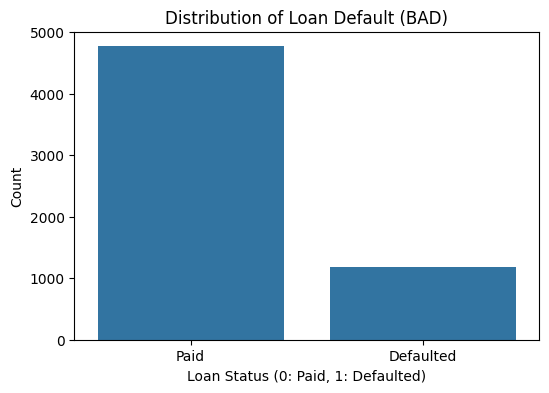

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='BAD', data=df)
plt.title('Distribution of Loan Default (BAD)')
plt.xlabel('Loan Status (0: Paid, 1: Defaulted)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Paid', 'Defaulted'])
plt.show()


Scatter plots between pairs of numerical features, potentially colored by the 'BAD' category, to explore relationships and see if they differ for defaulted loans.

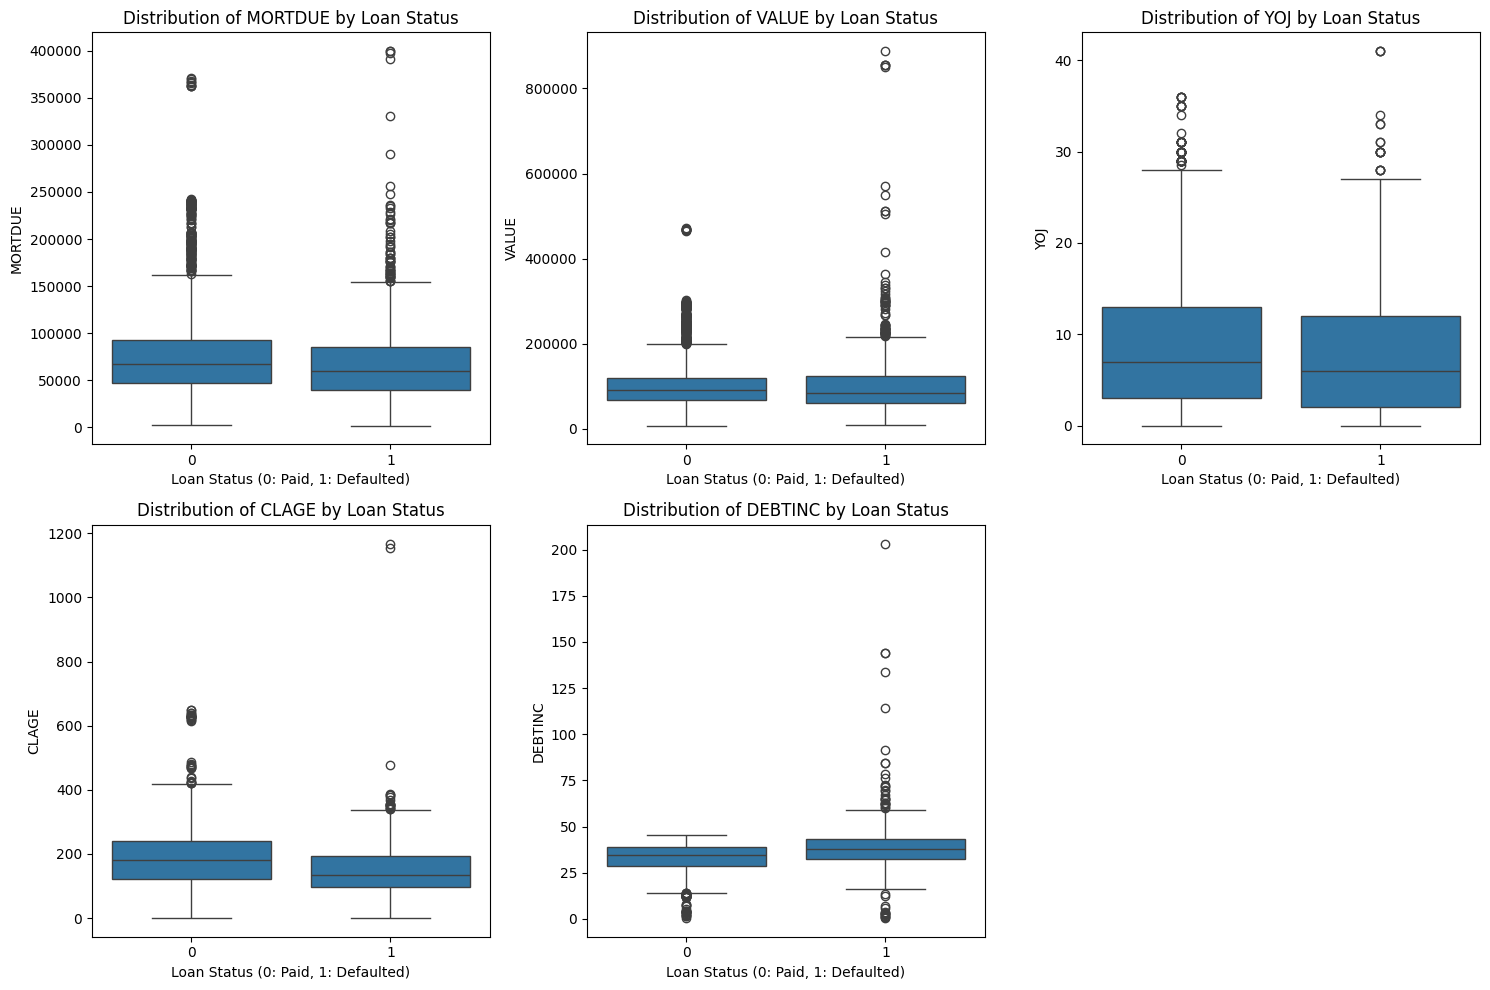

In [ ]:
numerical_features = ['MORTDUE', 'VALUE', 'YOJ', 'CLAGE', 'DEBTINC']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='BAD', y=feature, data=df)
    plt.title(f'Distribution of {feature} by Loan Status')
    plt.xlabel('Loan Status (0: Paid, 1: Defaulted)')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

 The counts of defaulted and paid loans within each job category.

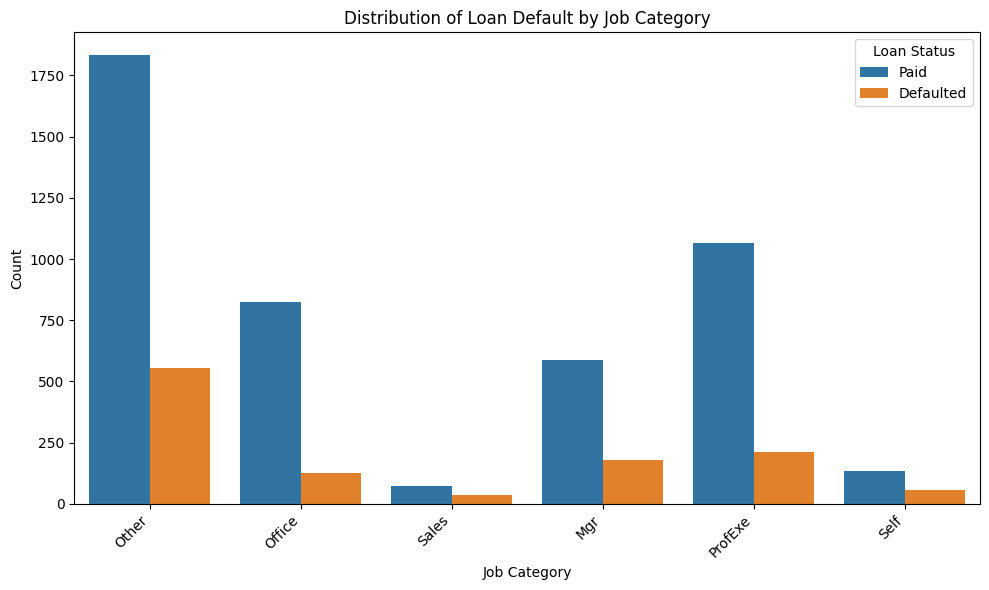

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='JOB', hue='BAD', data=df)
plt.title('Distribution of Loan Default by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Loan Status', labels=['Paid', 'Defaulted'])
plt.tight_layout()
plt.show()

 A heatmap to visualize the correlation between all numerical features. This can help identify highly correlated features

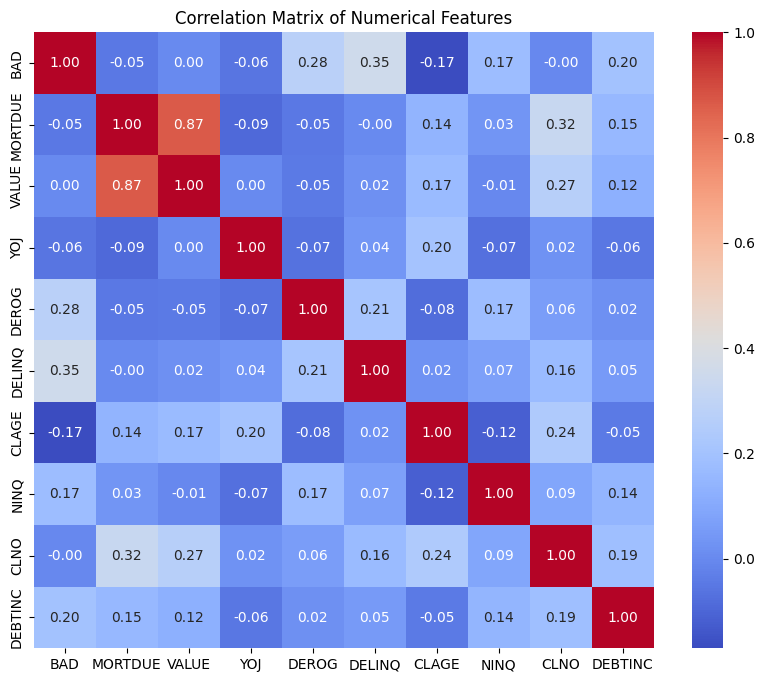

In [ ]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Task
Calculate credit risk RWA for the given data under both standardized and IRB approach and compare the results.

**Credit Risk RWA** represents the risk exposure of a bank's assets, weighted according to their level of credit risk. It is a crucial metric for banks as it determines the minimum amount of regulatory capital a bank must hold to absorb potential losses from credit defaults. A higher RWA means a bank is exposed to more credit risk and because of it needs to hold more capital.

**The Standardized Approach** is a method for calculating Credit Risk RWA that is relatively simple and less data-intensive compared to the IRB Approach. Under this approach, banks use external credit ratings from accredited rating agencies (like Moody's, Standard & Poor's, or Fitch) to determine the risk weight for different asset classes (e.g., corporate exposures, retail exposures, sovereign exposures). Each credit rating corresponds to a predetermined, fixed risk weight set by the regulators. For example, a corporate exposure with a high credit rating (e.g., AAA) will have a lower risk weight than an exposure with a lower rating (e.g., BB). This approach is considered a "one-size-fits-all" method, as it applies the same risk weights to all banks regardless of their internal risk management capabilities.

**The IRB Approach** is a more advanced and complex method for calculating Credit Risk RWA. Unlike the Standardized Approach, the IRB Approach allows banks to use their own internal models to estimate the key risk parameters for each credit exposure. These parameters include:
PD (Probability of Default)- the likelihood that a borrower will default on their obligation over a one-year horizon.
LGD (Loss Given Default) - the percentage of the exposure that a bank is expected to lose if a default occurs.
EAD (Exposure at Default)- the estimated outstanding amount of the exposure at the time of default.
Based on these internal estimates, along with other factors like maturity (M), banks use formulas provided by regulators to calculate the RWA for each exposure. There are two variations within the IRB Approach: Foundation IRB (F-IRB), where banks estimate PD and regulators provide LGD and EAD values, and Advanced IRB (A-IRB), where banks estimate all three parameters (PD, LGD, and EAD).
The key differences between the Standardized Approach and the IRB Approach lie in their complexity and data requirements.

**Complexity**. The Standardized Approach is less complex as it relies on external ratings and fixed risk weights. The IRB Approach is significantly more complex as it requires the development, validation, and ongoing monitoring of internal risk models.

**Data Requirement.** The Standardized Approach requires less detailed internal data. The IRB Approach, however, demands extensive historical data on defaults, losses, and exposures to accurately estimate PD, LGD, and EAD.

**Risk Sensitivity.** The IRB Approach is generally considered more risk-sensitive than the Standardized Approach because it allows banks to tailor their RWA calculations to their specific portfolio risk characteristics. The Standardized Approach, with its fixed weights, may not fully capture the nuances of a bank's risk profile.

**Regulatory Approval.** Banks need explicit regulatory approval to use the IRB Approach, which involves a rigorous validation process of their internal models and risk management framework. The Standardized Approach does not require such approval.

Credit Risk RWA represents the risk exposure of a bank's assets, weighted according to their level of credit risk. It is a crucial metric for banks as it determines the minimum amount of regulatory capital a bank must hold to absorb potential losses from credit defaults. A higher RWA means a bank is exposed to more credit risk and thus needs to hold more capital. This capital requirement is a cornerstone of prudential regulation, like the Basel framework, aimed at ensuring the stability and solvency of the banking system.

## Standardized approach (SA)

In this task I inspect the DataFrame to identify columns related to asset class and risk weights, then I can create the 'asset_class' and
'risk_weight' columns based on the assumption that all loans are residential mortgages.


In [ ]:
print(df.columns)
df['asset_class'] = 'Residential Mortgage'

# Assign a common risk weight for residential mortgages under the SA (e.g., 35%)
df['risk_weight'] = 0.35
display(df.head())

# Check the data types of the new columns
print(df[['asset_class', 'risk_weight']].info())

Index(['BAD', 'MORTDUE', 'VALUE', 'JOB', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE',
       'NINQ', 'CLNO', 'DEBTINC'],
      dtype='object')


,BAD,MORTDUE,VALUE,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,asset_class,risk_weight
0,1,25860.0,39025.0,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN,Residential Mortgage,0.35
1,1,70053.0,68400.0,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN,Residential Mortgage,0.35
2,1,13500.0,16700.0,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN,Residential Mortgage,0.35
3,1,NaN,89526.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Residential Mortgage,0.35
4,0,97800.0,112000.0,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN,Residential Mortgage,0.35


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   asset_class  5960 non-null   object 
 1   risk_weight  5960 non-null   float64
dtypes: float64(1), object(1)
memory usage: 93.3+ KB
None


## Calculate RWA - standardized approach

In this task I am implementing the calculation of RWA based on the rules of the Standardized Approach, that means, calculating the RWA for each loan and then sum them up to get the total RWA under the Standardized Approach.


In [ ]:
# Calculate RWA for each loan
df['rwa_standardized'] = df['MORTDUE'] * df['risk_weight']

# Calculate the total RWA for the portfolio
total_rwa_standardized = df['rwa_standardized'].sum()

# Print the total calculated RWA
print(f"Total RWA under Standardized Approach: {total_rwa_standardized:,.2f}")

Total RWA under Standardized Approach: 140,492,228.52


## Prepare data for IRB approach

In this task I ensure that the necessary parameters for the IRB Approach (e.g., Probability of Default (PD), Loss Given Default (LGD), Exposure at Default (EAD)) are available or can be estimated from the dataset. That takes identification and preparation the columns for PD, LGD, and EAD estimation, then estimate these values based on available data and add them to the DataFrame.



In [ ]:
# Estimate PD (Probability of Default)
# We can use the proportion of defaulted loans (BAD=1) in the dataset as
# a simple estimate for the overall PD.
# For individual loans, we can assign a PD based on whether they defaulted or not
# calculate the overall default rate and consider it as a baseline.
default_rate = df['BAD'].mean()
print(f"Estimated baseline Probability of Default (PD): {default_rate:.4f}")

# For individual loans, we can assign a PD based on the 'BAD' status.
df['estimated_PD'] = df['BAD']

# Estimate LGD (Loss Given Default)
# For mortgage loans, a common assumption for LGD is around 30-50% of
# the exposure, considering collateral.
# Let's assume a fixed LGD of 40%
df['estimated_LGD'] = 0.40
print(f"Assumed Loss Given Default (LGD): {df['estimated_LGD'].iloc[0]:.2f}")


# Estimate EAD (Exposure at Default)
# For a drawn mortgage loan, EAD is typically the outstanding balance at
# the time of default.
# We can use the 'MORTDUE' column as a simple estimate for EAD.
# Fill missing MORTDUE with the median for estimation.
median_mortdue = df['MORTDUE'].median()
df['MORTDUE'].fillna(median_mortdue, inplace=True)
df['estimated_EAD'] = df['MORTDUE']
print(f"Using MORTDUE as estimated Exposure at Default (EAD). Median MORTDUE used for filling missing values: {median_mortdue:.2f}")

# Display the first few rows with the new estimated columns
display(df[['BAD', 'estimated_PD', 'estimated_LGD', 'estimated_EAD']].head())

# Verify missing values in the new columns.
print("\nMissing values in new columns:")
print(df[['estimated_PD', 'estimated_LGD', 'estimated_EAD']].isnull().sum())

Estimated baseline Probability of Default (PD): 0.1995
Assumed Loss Given Default (LGD): 0.40
Using MORTDUE as estimated Exposure at Default (EAD). Median MORTDUE used for filling missing values: 65019.00


/tmp/ipython-input-3329534645.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MORTDUE'].fillna(median_mortdue, inplace=True)


,BAD,estimated_PD,estimated_LGD,estimated_EAD
0,1,1,0.4,25860.0
1,1,1,0.4,70053.0
2,1,1,0.4,13500.0
3,1,1,0.4,65019.0
4,0,0,0.4,97800.0



Missing values in new columns:
estimated_PD     0
estimated_LGD    0
estimated_EAD    0
dtype: int64


## Calculate RWA - IRB approach

In this task I implement the calculation of RWA based on the formulas of the IRB Approach.


In [ ]:
# Calculate the Risk-Weighted Assets (RWA) for each loan using the IRB formula
df['rwa_irb'] = df['estimated_PD'] * df['estimated_LGD'] * df['estimated_EAD'] * 12.5

# Calculate the total RWA for the portfolio by summing the 'rwa_irb' column
total_rwa_irb = df['rwa_irb'].sum()

# Print the total calculated RWA under the IRB Approach, formatted to two decimal places
print(f"Total RWA under IRB Approach: {total_rwa_irb:,.2f}")

Total RWA under IRB Approach: 410,588,422.85


## Compare Standardized and IRB results

In this task I compare the calculated RWA under both approaches and look at the differences.


In [ ]:
# Print the total RWA calculated under the Standardized Approach
print(f"Total RWA under Standardized Approach: {total_rwa_standardized:,.2f}")

# Print the total RWA calculated under the IRB Approach
print(f"Total RWA under IRB Approach: {total_rwa_irb:,.2f}")

# Calculate the difference between the total RWA under the IRB Approach and the Standardized Approach
rwa_difference = total_rwa_irb - total_rwa_standardized

# Print the calculated difference
print(f"Difference (IRB - Standardized): {rwa_difference:,.2f}")

Total RWA under Standardized Approach: 140,492,228.52
Total RWA under IRB Approach: 410,588,422.85
Difference (IRB - Standardized): 270,096,194.33


### Data Analysis Key Findings

*   The total Risk-Weighted Assets (RWA) calculated under the Standardized Approach is \$140,492,228.52.
*   The total RWA calculated under the IRB Approach is \$410,588,422.85.
*   The difference between the IRB RWA and the Standardized RWA is \$270,096,194.33, with the IRB approach resulting in a significantly higher RWA.

### Insights or Next Steps

*   The choice of calculation method has a big impact on how much money a bank needs to set aside for risk. The IRB method, while more complicated, can give a more accurate picture of a bank's risk. However, since the analysis used some simple assumptions, the final results might show a much bigger difference than you'd see in the real world.

*   For a more accurate IRB calculation and comparison, developing robust internal models for estimating PD, LGD, and EAD based on historical data and other relevant factors would be necessary.
